# Занятие 2. Предобработка и аугментации
## Нейросетевые методы обработки изображений

В этом ноутбуке мы:
1. Разберём базовые операции предобработки (Resize, CenterCrop, Normalize).
2. Напишем собственный класс Dataset.
3. Реализуем пайплайны аугментаций: flip, rotate, crop, color jitter.
4. Визуализируем эффект каждой аугментации.
5. Разберём синхронные аугментации для сегментации.
6. Составим мини-отчёт: какие аугментации уместны для каких задач.

---
## Шаг 1. Установка зависимостей

Для занятия нужна библиотека albumentations — специально разработана
для аугментаций с поддержкой масок, bounding boxes, keypoints.

In [2]:
#!pip install albumentations

   ---------------------------------------- 0.0/868.1 kB ? eta -:--:--
   --------------------------------------- 868.1/868.1 kB 30.5 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [stringzilla]
   ------------------------------ --------- 3/4 [albumentations]
   ------------------------------ --------- 3/4 [albumentations]
   ---------------------------------------- 4/4 [albumentations]



In [5]:
# Раскомментируйте при необходимости:
# !pip install albumentations

import importlib

libs = {
    "torch":          "PyTorch",
    "torchvision":    "TorchVision",
    "PIL":            "Pillow",
    "matplotlib":     "Matplotlib",
    "numpy":          "NumPy",
    "albumentations": "Albumentations",
}
for pkg, name in libs.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "?")
        print(f"[OK]  {name}: {ver}")
    except ImportError:
        print(f"[НЕТ] {name}: установите через pip")

[OK]  PyTorch: 2.13.0+cpu
[OK]  TorchVision: 0.28.0+cpu
[OK]  Pillow: 11.1.0
[OK]  Matplotlib: 3.10.0
[OK]  NumPy: 2.1.3
[OK]  Albumentations: 2.0.8


---
## Шаг 2. Импорты и загрузка датасета

Загрузим CIFAR-10 без трансформаций, чтобы получить сырые PIL Image.

In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# transform=None: датасет возвращает PIL Image напрямую
raw_dataset = torchvision.datasets.CIFAR10(
    root="./cifar", train=True, download=False, transform=None
)

class_names = raw_dataset.classes
print(f"Датасет загружен: {len(raw_dataset)} изображений")
print(f"Классы: {class_names}")

sample_img, sample_label = raw_dataset[0]
print(f"\nТип элемента:  {type(sample_img)}")
print(f"Размер PIL:    {sample_img.size}  (ширина x высота)")
print(f"Метка:         {sample_label} ({class_names[sample_label]})")

Датасет загружен: 50000 изображений
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Тип элемента:  <class 'PIL.Image.Image'>
Размер PIL:    (32, 32)  (ширина x высота)
Метка:         6 (frog)


backend: Agg


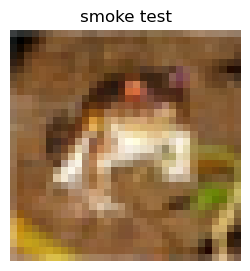

In [7]:
import matplotlib
print("backend:", matplotlib.get_backend())

%matplotlib inline

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(np.array(raw_dataset[0][0]))
ax.set_title("smoke test")
ax.axis("off")
plt.show()
plt.close(fig)

---
## Шаг 3. Базовые операции предобработки

Обязательные операции для всех выборок: Resize -> ToTensor -> Normalize.
CenterCrop добавляется на val/test для детерминированного кадрирования.

In [8]:
# Resize -----------------------------------------------------------------
# Одно число: меньшая сторона = этому числу, пропорции сохраняются
# Кортеж (H, W): строгий ресайз без сохранения пропорций
resize_op   = transforms.Resize(64)
img_resized = resize_op(sample_img)
print(f"Оригинал:          {sample_img.size}")
print(f"После Resize(64):  {img_resized.size}")

# CenterCrop -------------------------------------------------------------
# Вырезает центральный квадрат. Типичный val-пайплайн: Resize(256) -> CenterCrop(224)
centercrop_op = transforms.CenterCrop(56)
img_cropped   = centercrop_op(img_resized)
print(f"После CenterCrop(56): {img_cropped.size}")

# ToTensor ---------------------------------------------------------------
# PIL Image (H,W,C) uint8 [0,255] -> тензор (C,H,W) float32 [0.0, 1.0]
to_tensor_op = transforms.ToTensor()
img_tensor   = to_tensor_op(img_cropped)
print(f"\nПосле ToTensor: {img_tensor.shape}, [{img_tensor.min():.2f}, {img_tensor.max():.2f}]")

# Normalize --------------------------------------------------------------
# pixel_norm = (pixel - mean) / std
# ImageNet mean/std — стандарт для transfer learning
normalize_op = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)
img_norm = normalize_op(img_tensor)
print(f"После Normalize: {img_norm.shape}, [{img_norm.min():.2f}, {img_norm.max():.2f}]")
print("\nОтрицательные значения после нормализации — норма!")
print("Для matplotlib используйте np.clip(img, 0, 1)")

Оригинал:          (32, 32)
После Resize(64):  (64, 64)
После CenterCrop(56): (56, 56)

После ToTensor: torch.Size([3, 56, 56]), [0.02, 0.99]
После Normalize: torch.Size([3, 56, 56]), [-1.72, 2.32]

Отрицательные значения после нормализации — норма!
Для matplotlib используйте np.clip(img, 0, 1)


---
## Шаг 4. Train- и val-пайплайны через transforms.Compose

Главное правило: аугментации только в train-пайплайне.
Val/test — только предобработка, детерминированная, без случайности.

In [9]:
# Train-пайплайн (с аугментациями) ----------------------------------------
train_transform = transforms.Compose([
    transforms.Resize(40),              # делаем чуть больше целевого
    transforms.RandomCrop(32),          # случайный кроп до целевого 32x32
    transforms.RandomHorizontalFlip(p=0.5),  # горизонтальное отражение
    transforms.ColorJitter(
        brightness=0.2,   # диапазон [0.8, 1.2] яркости
        contrast=0.2,     # диапазон [0.8, 1.2] контраста
        saturation=0.2,   # диапазон [0.8, 1.2] насыщенности
        hue=0.05          # диапазон [-0.05, +0.05] оттенка
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),  # CIFAR-10 mean по каналам
        std=(0.2470, 0.2435, 0.2616)    # CIFAR-10 std по каналам
    ),
])

# Val/Test-пайплайн (только предобработка) ---------------------------------
val_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),  # детерминированный кроп
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./cifar", train=True,  download=False, transform=train_transform
)
val_dataset = torchvision.datasets.CIFAR10(
    root="./cifar", train=False, download=False, transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)

print(f"Train DataLoader: {len(train_loader)} батчей по 64 изображения")
print(f"Val   DataLoader: {len(val_loader)} батчей по 64 изображения")

Train DataLoader: 782 батчей по 64 изображения
Val   DataLoader: 157 батчей по 64 изображения


---
## Шаг 5. Визуализация отдельных аугментаций

Применим каждую аугментацию 10 раз к одному изображению.
Это наглядно показывает разброс случайных трансформаций.

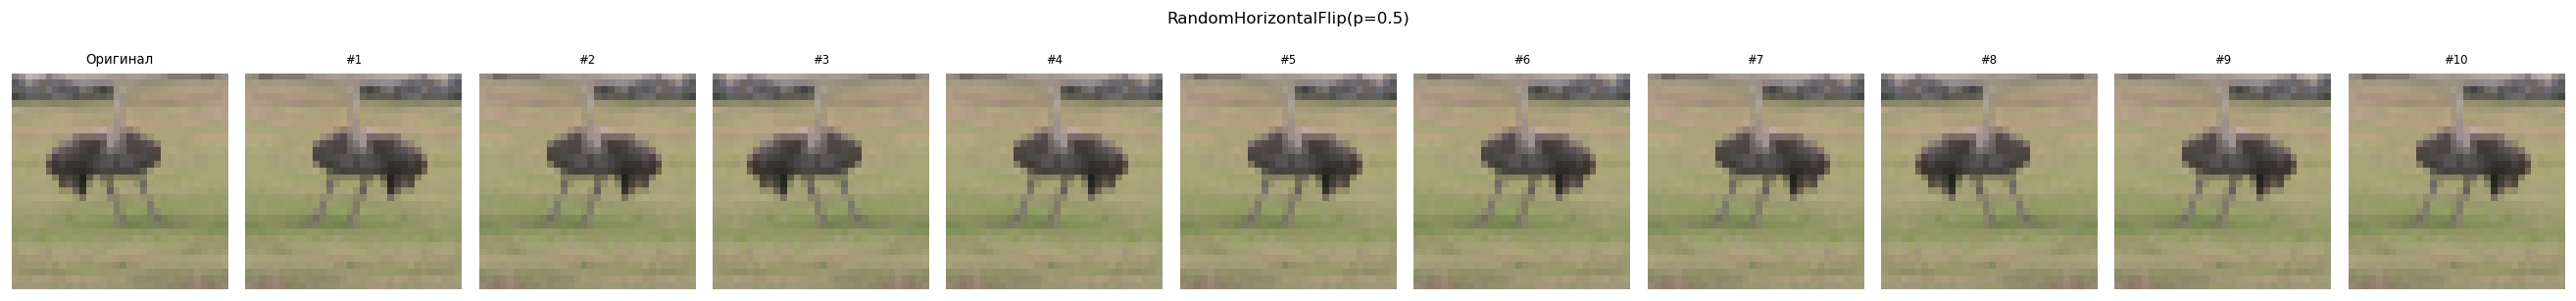

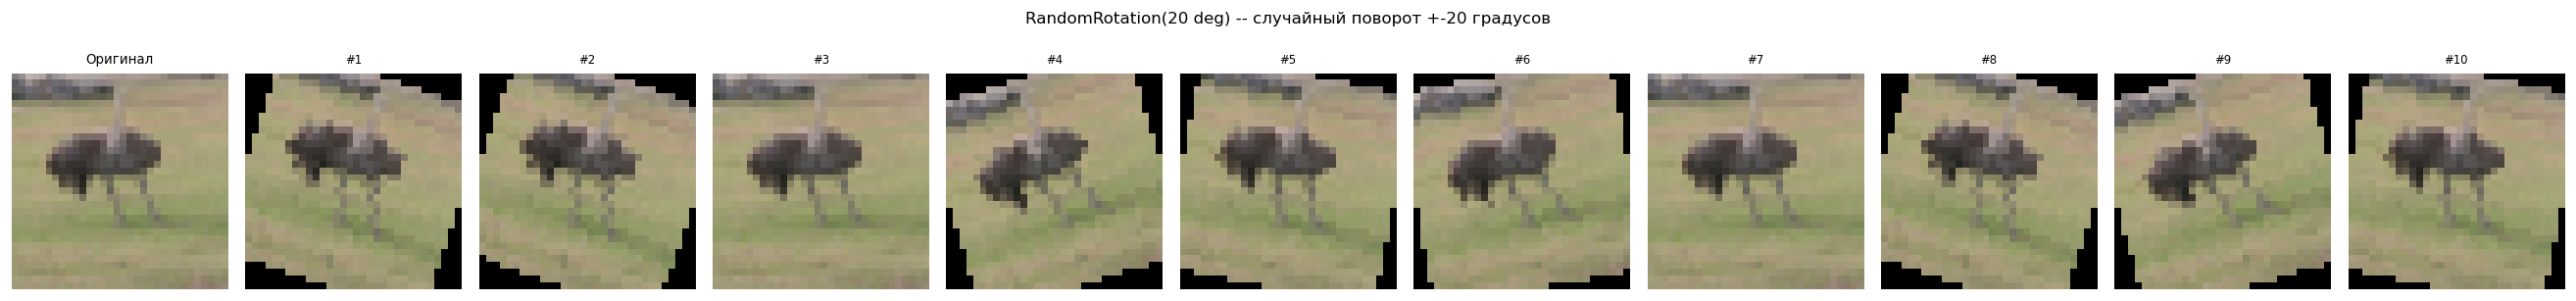

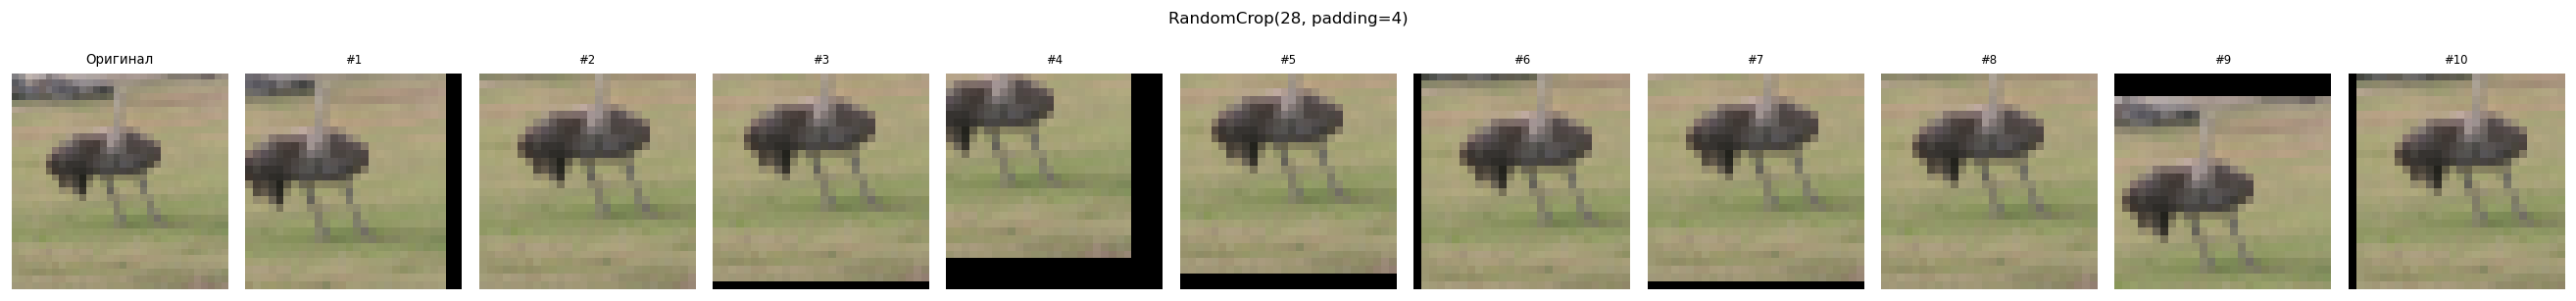

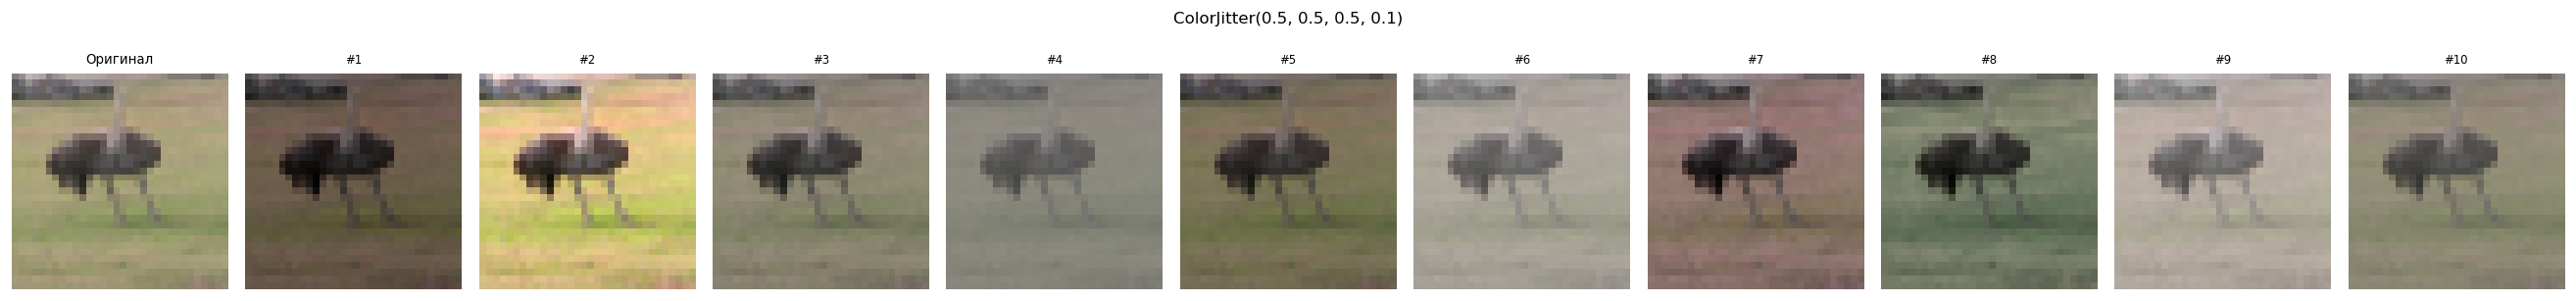

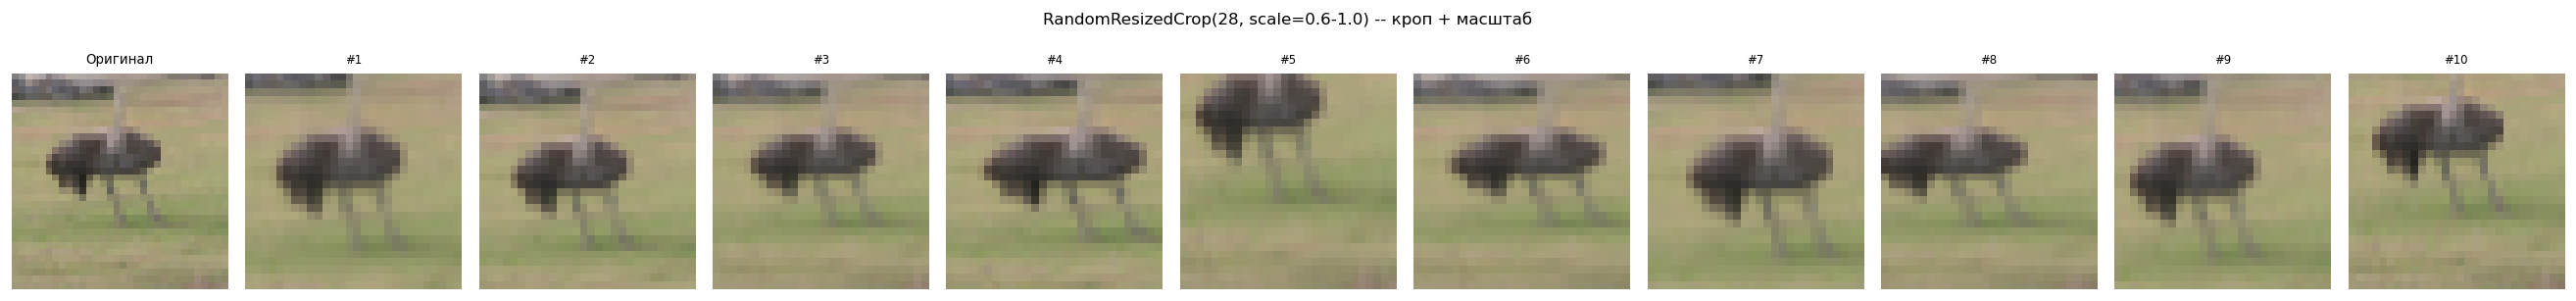

In [11]:
import io
from IPython.display import display, Image as IPyImage

pil_img, label = raw_dataset[42]

def show_augmentations(pil_img, transform, title, n=10):
    fig, axes = plt.subplots(1, n + 1, figsize=(22, 2.5))
    axes[0].imshow(pil_img)
    axes[0].set_title("Оригинал", fontsize=8)
    axes[0].axis("off")
    for i in range(1, n + 1):
        aug = transform(pil_img)
        if isinstance(aug, torch.Tensor):
            img_np = np.clip(aug.permute(1, 2, 0).numpy(), 0, 1)
        else:
            img_np = np.array(aug)
        axes[i].imshow(img_np)
        axes[i].set_title(f"#{i}", fontsize=7)
        axes[i].axis("off")
    plt.suptitle(title, fontsize=10, y=1.02)
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    buf.seek(0)
    display(IPyImage(data=buf.getvalue()))


# 1. RandomHorizontalFlip: p=0.5 -- примерно половина зеркально отражена
show_augmentations(pil_img, transforms.RandomHorizontalFlip(p=0.5),
    "RandomHorizontalFlip(p=0.5)")

# 2. RandomRotation: случайный поворот +-20 градусов
show_augmentations(pil_img, transforms.RandomRotation(degrees=20),
    "RandomRotation(20 deg) -- случайный поворот +-20 градусов")

# 3. RandomCrop: отступ 4px + случайный кроп до 28x28
show_augmentations(pil_img, transforms.RandomCrop(28, padding=4),
    "RandomCrop(28, padding=4)")

# 4. ColorJitter: случайное изменение яркости/контраста/насыщенности/оттенка
show_augmentations(
    pil_img,
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    "ColorJitter(0.5, 0.5, 0.5, 0.1)"
)

# 5. RandomResizedCrop: стандарт ImageNet -- случайный кроп + ресайз
show_augmentations(
    pil_img,
    transforms.RandomResizedCrop(size=28, scale=(0.6, 1.0)),
    "RandomResizedCrop(28, scale=0.6-1.0) -- кроп + масштаб"
)

---
## Шаг 6. Написание собственного класса Dataset

Три обязательных метода:
- __init__: инициализация, пути, метки, трансформации
- __len__: общее количество элементов
- __getitem__: загрузка одного элемента по индексу

In [ ]:
import os
from pathlib import Path

class ImageFolderDataset(Dataset):
    EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")

    def __init__(self, root, transform=None):
        self.root      = Path(root)
        self.transform = transform
        # Список классов -- имена поддиректорий, по алфавиту
        self.classes      = sorted(d.name for d in self.root.iterdir() if d.is_dir())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        # Список пар (путь_к_файлу, индекс_класса)
        self.samples = [
            (str(fpath), self.class_to_idx[cls])
            for cls in self.classes
            for fpath in (self.root / cls).iterdir()
            if fpath.suffix.lower() in self.EXTS
        ]

    def __len__(self):
        # DataLoader вызывает __len__ для расчёта количества батчей
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # .convert("RGB") -- 3 канала для PNG/RGBA/grayscale
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


# Демонстрация: сохраняем несколько CIFAR-10 на диск ---------------------
demo_dir = "./demo_dataset"
for cls in ["airplane", "automobile"]:
    os.makedirs(f"{demo_dir}/{cls}", exist_ok=True)

counts = {"airplane": 0, "automobile": 0}
for img, lbl in raw_dataset:
    cls_name = class_names[lbl]
    if cls_name in counts and counts[cls_name] < 8:
        img.save(f"{demo_dir}/{cls_name}/{counts[cls_name]}.png")
        counts[cls_name] += 1
    if all(v >= 8 for v in counts.values()):
        break

print(f"Сохранено: {counts}")

demo_ds = ImageFolderDataset(
    root=demo_dir,
    transform=transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
)
print(f"Классы:          {demo_ds.classes}")
print(f"class_to_idx:    {demo_ds.class_to_idx}")
print(f"Всего элементов: {len(demo_ds)}")

img_t, lbl = demo_ds[0]
print(f"\nОдин элемент: тензор {img_t.shape}, метка {lbl} ({demo_ds.classes[lbl]})")

---
## Шаг 7. DataLoader с кастомным Dataset

In [ ]:
demo_loader = DataLoader(
    demo_ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    drop_last=False
)

print(f"Батчей в DataLoader: {len(demo_loader)}")
for batch_idx, (images, labels) in enumerate(demo_loader):
    print(f"  Батч {batch_idx}: images={images.shape}, labels={labels.tolist()}")

print("\nКомментарий:")
print("  images.shape = [batch_size, C, H, W]")
print("  labels.shape = [batch_size]")

---
## Шаг 8. Сравнение train- и val-пайплайнов

Train: каждый раз разный результат (случайные аугментации).
Val: всегда одинаковый результат (детерминированная предобработка).

In [ ]:
pil_img, label = raw_dataset[100]
train_results = [train_transform(pil_img) for _ in range(4)]
val_results   = [val_transform(pil_img)   for _ in range(4)]

fig, axes = plt.subplots(3, 5, figsize=(14, 8))

axes[0][0].imshow(pil_img)
axes[0][0].set_title("Оригинал")
axes[0][0].axis("off")
for j in range(1, 5):
    axes[0][j].axis("off")

for j, t in enumerate(train_results):
    img_np = np.clip(t.permute(1,2,0).numpy(), 0, 1)
    axes[1][j].imshow(img_np)
    axes[1][j].set_title(f"Train #{j+1}", fontsize=8)
    axes[1][j].axis("off")

for j, v in enumerate(val_results):
    img_np = np.clip(v.permute(1,2,0).numpy(), 0, 1)
    axes[2][j].imshow(img_np)
    axes[2][j].set_title(f"Val #{j+1}", fontsize=8)
    axes[2][j].axis("off")

axes[1][0].set_ylabel("Train (случайный)", fontsize=9)
axes[2][0].set_ylabel("Val (детерм.)", fontsize=9)
plt.suptitle(f"Train vs Val пайплайн -- {class_names[label]}", fontsize=12)
plt.tight_layout()
plt.show()

---
## Шаг 9. Аугментации для сегментации: синхронное преобразование

Маска -- это пиксельная разметка H x W, где каждый пиксель -- индекс класса.
Геометрические трансформации применяются синхронно к img и mask.
Маска поворачивается с интерполяцией NEAREST -- без смешивания меток.

In [ ]:
import random

# Синтетическое изображение + маска (круг = объект)
np.random.seed(0)
demo_img_np = np.random.randint(50, 200, (128, 128, 3), dtype=np.uint8)
ys, xs = np.ogrid[:128, :128]
demo_mask_np = ((xs - 64)**2 + (ys - 64)**2 < 30**2).astype(np.uint8)

demo_img_pil  = Image.fromarray(demo_img_np)
demo_mask_pil = Image.fromarray(demo_mask_np * 255)


def seg_augment(image, mask):
    # 1. Горизонтальный флип -- решаем один раз для обоих
    if random.random() > 0.5:
        image = TF.hflip(image)
        mask  = TF.hflip(mask)

    # 2. Поворот -- один угол для img и mask
    angle = random.uniform(-15, 15)
    image = TF.rotate(image, angle)
    # NEAREST: не смешивать метки классов при интерполяции
    mask  = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

    # 3. Crop -- одни координаты для обоих
    i, j, h, w = transforms.RandomCrop.get_params(image, output_size=(96, 96))
    image = TF.crop(image, i, j, h, w)
    mask  = TF.crop(mask,  i, j, h, w)

    # 4. ColorJitter -- ТОЛЬКО для изображения
    image = transforms.ColorJitter(brightness=0.3, contrast=0.3)(image)

    # 5. Изображение: PIL -> тензор C x H x W float32 [0,1]
    image = TF.to_tensor(image)

    # 6. Маска: numpy -> тензор long, значения 0 или 1
    mask  = torch.from_numpy(np.array(mask) // 255).long()

    return image, mask


fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes[0][0].imshow(demo_img_np)
axes[0][0].set_title("Оригинал"); axes[0][0].axis("off")
axes[1][0].imshow(demo_mask_np, cmap="gray")
axes[1][0].set_title("Маска"); axes[1][0].axis("off")

for col in range(1, 5):
    aug_img, aug_mask = seg_augment(demo_img_pil, demo_mask_pil)
    axes[0][col].imshow(aug_img.permute(1,2,0).numpy())
    axes[0][col].set_title(f"Вариант {col}"); axes[0][col].axis("off")
    axes[1][col].imshow(aug_mask.numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1][col].set_title(f"Маска {col}"); axes[1][col].axis("off")

axes[0][0].set_ylabel("Изображение", fontsize=9)
axes[1][0].set_ylabel("Маска", fontsize=9)
plt.suptitle("Синхронная аугментация: functional API", fontsize=12)
plt.tight_layout()
plt.show()

print("Ключевые моменты:")
print("  - Угол поворота один для img и mask")
print("  - Координаты кропа одни для обоих")
print("  - Маска: интерполяция NEAREST")
print("  - ColorJitter только к изображению!")

---
## Шаг 10. Albumentations: пайплайн для сегментации

albumentations принимает словарь {"image": ..., "mask": ...}
и автоматически синхронизирует геометрические трансформации.

In [ ]:
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    HAS_ALB = True
except ImportError:
    HAS_ALB = False
    print("albumentations не установлен: pip install albumentations")

if HAS_ALB:
    # Пайплайн для классификации ----------------------------------------
    clf_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.2, hue=0.05, p=0.8),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),   # numpy H x W x C -> тензор C x H x W
    ])

    # Пайплайн для сегментации ------------------------------------------
    # Геометрика синхронизируется автоматически.
    # ColorJitter и Normalize -- pixel-level: только к img.
    seg_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomCrop(height=96, width=96, p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    img_np  = np.array(demo_img_pil)
    mask_np = (np.array(demo_mask_pil) > 0).astype(np.uint8)

    fig, axes = plt.subplots(2, 5, figsize=(18, 6))
    axes[0][0].imshow(img_np)
    axes[0][0].set_title("Оригинал"); axes[0][0].axis("off")
    axes[1][0].imshow(mask_np, cmap="gray")
    axes[1][0].set_title("Маска"); axes[1][0].axis("off")

    for col in range(1, 5):
        result = seg_transform(image=img_np, mask=mask_np)
        aug_img  = result["image"]
        aug_mask = result["mask"]
        axes[0][col].imshow(np.clip(aug_img.permute(1,2,0).numpy(), 0, 1))
        axes[0][col].set_title(f"Вариант {col}"); axes[0][col].axis("off")
        axes[1][col].imshow(aug_mask.numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1][col].set_title(f"Маска {col}"); axes[1][col].axis("off")

    axes[0][0].set_ylabel("Изображение", fontsize=9)
    axes[1][0].set_ylabel("Маска", fontsize=9)
    plt.suptitle("Albumentations: синхронная аугментация img + mask", fontsize=12)
    plt.tight_layout()
    plt.show()

    print("Единый пайплайн: синхронизируемся автоматически.")

---
## Шаг 11. Мини-отчёт: совместимость аугментаций с задачами CV

In [ ]:
import matplotlib.pyplot as plt

augs = [
    "RandomHorizontalFlip",
    "RandomVerticalFlip",
    "RandomRotation (+-10 deg)",
    "RandomRotation (+-90/180 deg)",
    "RandomCrop",
    "RandomResizedCrop",
    "ColorJitter",
    "GaussianBlur",
    "RandomErasing/Cutout",
    "Normalize",
]

# Столбцы: Классиф., Детекция, Сегментация, Замечание
data = [
    ("OK", "OK", "OK sync",     "Стандартная, почти везде"),
    ("!",  "!",  "! sync",      "RS, гистология, спутники"),
    ("OK", "OK", "OK sync",     "Маску с NEAREST"),
    ("!",  "!",  "! sync",      "Только RS и медицина"),
    ("OK", "OK", "OK sync",     "С padding для малых img"),
    ("OK", "!",  "OK sync",     "Стандарт ImageNet"),
    ("OK", "OK", "img only",    "Не применять к маске!"),
    ("OK", "OK", "img only",    "Имитирует расфокус"),
    ("OK", "!",  "ostorozhno",  "Не стирать ключевые объекты"),
    ("OK", "OK", "img only",    "Только к изображению!"),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

col_labels = ["Аугментация", "Классиф.", "Детекция", "Сегментация", "Замечание"]
table_data = [[aug] + list(row) for aug, row in zip(augs, data)]

tbl = ax.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc="center", loc="center", bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor("#2e6fa3")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")
for i in range(1, len(augs) + 1):
    color = "#f0f4fa" if i % 2 == 0 else "white"
    for j in range(len(col_labels)):
        tbl[(i, j)].set_facecolor(color)

plt.title("Совместимость аугментаций с задачами CV", fontsize=12, pad=6)
plt.tight_layout()
plt.show()

print("Ключевые выводы:")
print("  1. Аугментации -- ТОЛЬКО на train.")
print("  2. Геометрика для сегментации: синхронно, маска с NEAREST.")
print("  3. ColorJitter и Normalize -- только к изображению.")
print("  4. VerticalFlip и большие углы: для RS/медицины.")
print("  5. albumentations рекомендуется для сегментации/детекции.")

---
## Итоговая таблица

| Тема | Результат |
|---|---|
| Предобработка | Resize, CenterCrop, ToTensor, Normalize |
| Пайплайны | transforms.Compose для train и val |
| Кастомный Dataset | __init__, __len__, __getitem__ |
| Аугментации | Flip, Rotation, Crop, ColorJitter, ResizedCrop |
| Сегментация | Синхронная аугментация через functional API |
| Albumentations | Пайплайн для seg: img+mask синхронно |
| Мини-отчёт | Таблица совместимости с задачами CV |

---
## Домашнее задание

1. Обучите простую свёрточную сеть (3-4 слоя) на CIFAR-10 **без аугментаций**.
   Запишите accuracy на тестовой выборке.
2. Добавьте пайплайн: RandomCrop(32, padding=4) + RandomHorizontalFlip(0.5)
   + ColorJitter(0.2, 0.2, 0.2, 0.05). Обучите ту же сеть. Сравните точность.
3. Уберите только ColorJitter. Как изменился результат?
4. (Дополнительно) Создайте Dataset для любого датасета изображений на диске.
   Убедитесь, что DataLoader возвращает правильную форму батча.
5. (Дополнительно) Реализуйте Dataset для сегментации: __getitem__ возвращает
   кортеж (image_tensor, mask_tensor). Проверьте синхронность аугментаций.